<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Epoch   1/100 | LR: 6.78e-05 | train loss 0.8697 acc 0.701 | val loss 0.5477 acc 0.768 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 6.78e-05 | train loss 0.6293 acc 0.767 | val loss 0.5564 acc 0.768


[ConvNeXt-Tiny] Epoch   3/100 | LR: 6.78e-05 | train loss 0.5496 acc 0.795 | val loss 0.6456 acc 0.748


[ConvNeXt-Tiny] Epoch   4/100 | LR: 6.78e-05 | train loss 0.4966 acc 0.815 | val loss 0.5062 acc 0.771 *


[ConvNeXt-Tiny] Epoch   5/100 | LR: 6.78e-05 | train loss 0.4337 acc 0.848 | val loss 0.7483 acc 0.713


...

[ConvNeXt-Tiny] Epoch  13/100 | LR: 6.78e-05 | train loss 0.2303 acc 0.921 | val loss 0.4268 acc 0.827


[ConvNeXt-Tiny] Epoch  14/100 | LR: 6.78e-05 | train loss 0.1642 acc 0.950 | val loss 0.5697 acc 0.824


[ConvNeXt-Tiny] Epoch  15/100 | LR: 6.78e-05 | train loss 0.1766 acc 0.946 | val loss 0.5951 acc 0.821


[ConvNeXt-Tiny] Epoch  16/100 | LR: 6.78e-05 | train loss 0.1379 acc 0.958 | val loss 0.5111 acc 0.848


[ConvNeXt-Tiny] Epoch  17/100 | LR: 6.78e-05 | train loss 0.1318 acc 0.956 | val loss 0.4938 acc 0.859

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 17.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.4052)


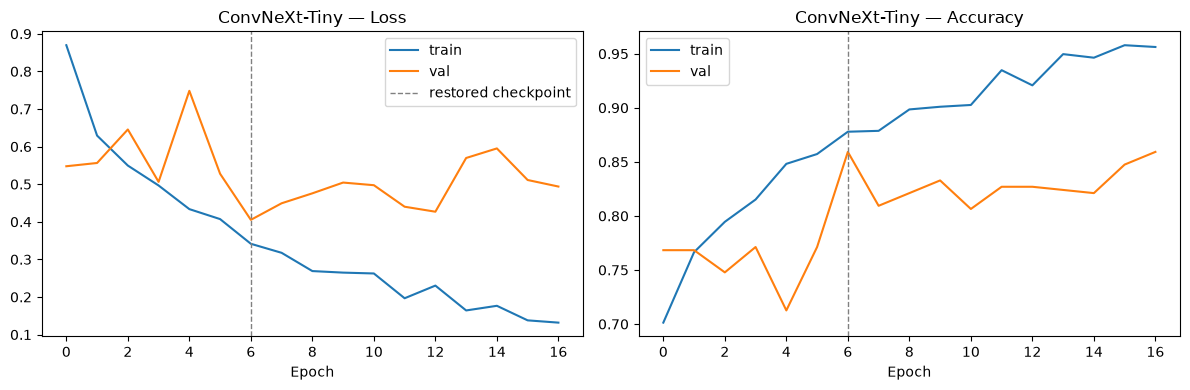

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.795


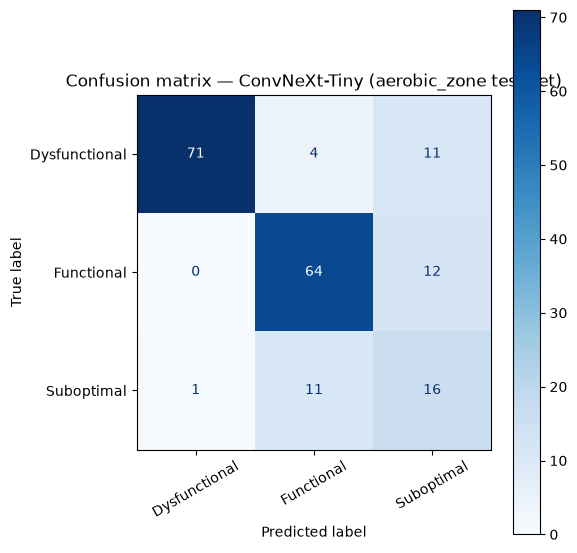

               precision    recall  f1-score   support

Dysfunctional      0.986     0.826     0.899        86
   Functional      0.810     0.842     0.826        76
   Suboptimal      0.410     0.571     0.478        28

     accuracy                          0.795       190
    macro avg      0.735     0.746     0.734       190
 weighted avg      0.831     0.795     0.808       190



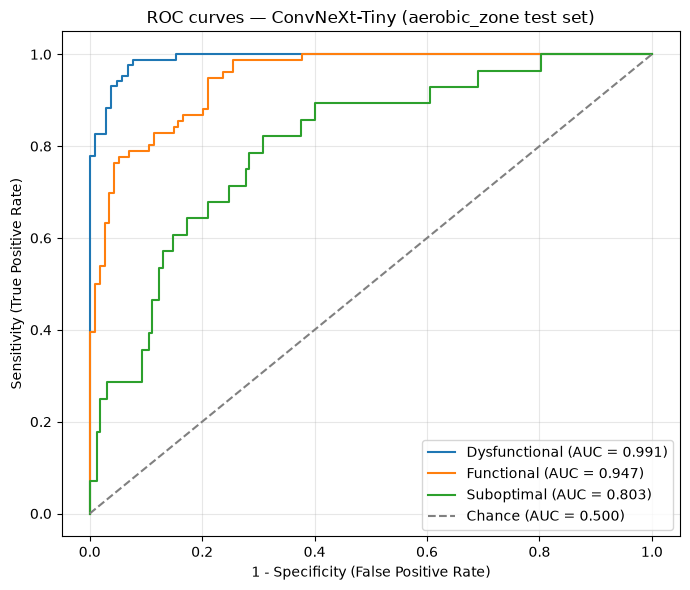

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.991
  Functional     : 0.947
  Suboptimal     : 0.803

Mean AUC (over 3/3 classes with test examples): 0.914


(np.float64(0.7947368421052632),
 {'Dysfunctional': 0.990608228980322,
  'Functional': 0.9472530009233611,
  'Suboptimal': 0.8029100529100529})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_convnext_tiny_stratified.pkl
Saved model weights to ../models/aerobic_zone_convnext_tiny_cnn.pt
